<a href="https://colab.research.google.com/github/pratik04032/All-Python-Programme/blob/main/AOCD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

base_path = "/content/drive/MyDrive/Colab Notebooks/classification_dataset"

train_path = os.path.join(base_path, "train")
valid_path = os.path.join(base_path, "valid")
test_path  = os.path.join(base_path, "test")

print("Train Path:", train_path)
print("Valid Path:", valid_path)
print("Test Path :", test_path)

Train Path: /content/drive/MyDrive/Colab Notebooks/classification_dataset/train
Valid Path: /content/drive/MyDrive/Colab Notebooks/classification_dataset/valid
Test Path : /content/drive/MyDrive/Colab Notebooks/classification_dataset/test


In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import ResNet50, MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [ ]:
def count_images(folder):
    class_counts = {}
    for class_name in os.listdir(folder):
        class_folder = os.path.join(folder, class_name)
        if os.path.isdir(class_folder):
            class_counts[class_name] = len(os.listdir(class_folder))
    return class_counts

train_counts = count_images(train_path)
valid_counts = count_images(valid_path)
test_counts = count_images(test_path)

print("TRAIN:", train_counts)
print("VALID:", valid_counts)
print("TEST :", test_counts)

TRAIN: {'drone': 1248, 'bird': 1414}
VALID: {'bird': 217, 'drone': 225}
TEST : {'bird': 121, 'drone': 94}


In [ ]:
dataset_summary = pd.DataFrame({
    "Train": train_counts,
    "Valid": valid_counts,
    "Test": test_counts
}).fillna(0).astype(int)

dataset_summary

,Train,Valid,Test
drone,1248,225,94
bird,1414,217,121


<Figure size 800x500 with 0 Axes>

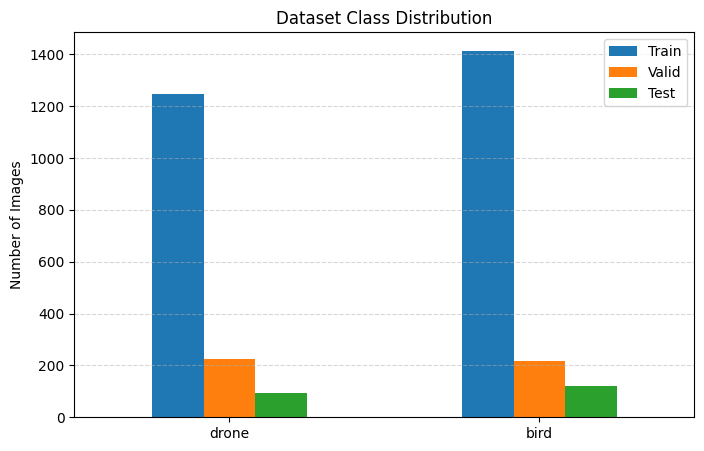

In [ ]:
plt.figure(figsize=(8,5))
dataset_summary.plot(kind='bar', figsize=(8,5))
plt.title("Dataset Class Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
print("Train difference :", abs(train_counts["bird"] - train_counts["drone"]))
print("Valid difference :", abs(valid_counts["bird"] - valid_counts["drone"]))
print("Test difference  :", abs(test_counts["bird"] - test_counts["drone"]))

Train difference : 166
Valid difference : 8
Test difference  : 27


In [ ]:
if train_counts["bird"] > train_counts["drone"]:
    print("Slight class imbalance in TRAIN: bird > drone")
elif train_counts["bird"] < train_counts["drone"]:
    print("Slight class imbalance in TRAIN: drone > bird")
else:
    print("Balanced training set")

Slight class imbalance in TRAIN: bird > drone


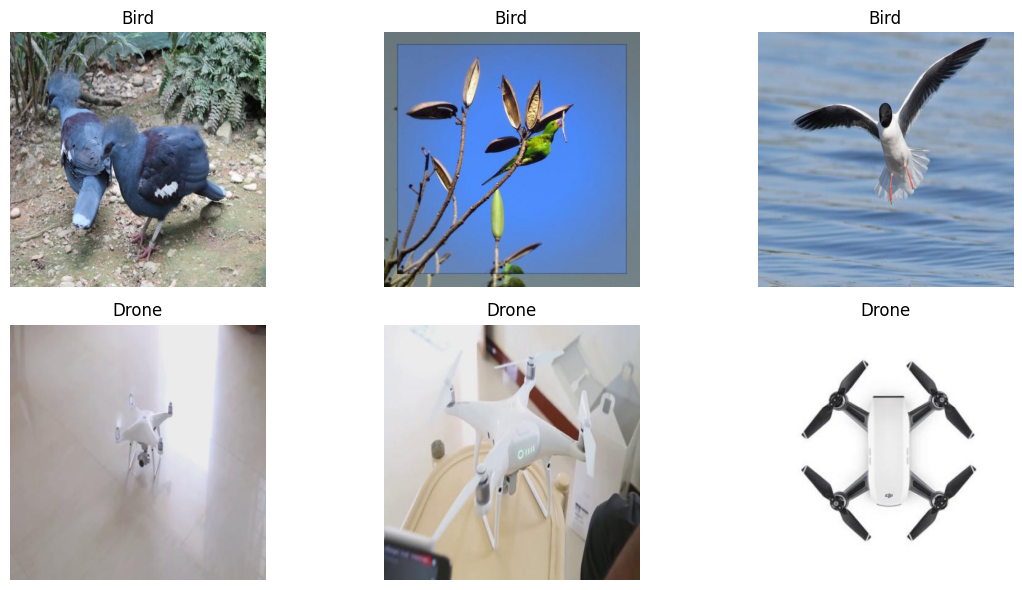

In [ ]:
bird_folder = os.path.join(train_path, "bird")
drone_folder = os.path.join(train_path, "drone")

bird_images = os.listdir(bird_folder)
drone_images = os.listdir(drone_folder)

plt.figure(figsize=(12,6))

for i in range(3):
    img = Image.open(os.path.join(bird_folder, random.choice(bird_images)))
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title("Bird")
    plt.axis("off")

for i in range(3):
    img = Image.open(os.path.join(drone_folder, random.choice(drone_images)))
    plt.subplot(2,3,i+4)
    plt.imshow(img)
    plt.title("Drone")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode="binary"
)

valid_ds_raw = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode="binary"
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode="binary",
    shuffle=False
)

class_names = train_ds_raw.class_names
print("Class Names:", class_names)

Found 2662 files belonging to 2 classes.
Found 442 files belonging to 2 classes.
Found 215 files belonging to 2 classes.
Class Names: ['bird', 'drone']


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomCrop(224, 224)
], name="data_augmentation")

print(data_augmentation)

<Sequential name=data_augmentation, built=False>


In [ ]:
def prepare_cnn_dataset(ds, training=False):
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds_cnn = prepare_cnn_dataset(train_ds_raw, training=True)
valid_ds_cnn = prepare_cnn_dataset(valid_ds_raw, training=False)
test_ds_cnn  = prepare_cnn_dataset(test_ds_raw, training=False)

In [ ]:
def prepare_resnet_dataset(ds, training=False):
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32), y), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda x, y: (resnet_preprocess(x), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds_resnet = prepare_resnet_dataset(train_ds_raw, training=True)
valid_ds_resnet = prepare_resnet_dataset(valid_ds_raw, training=False)
test_ds_resnet  = prepare_resnet_dataset(test_ds_raw, training=False)

In [ ]:
def prepare_mobilenet_dataset(ds, training=False):
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32), y), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda x, y: (mobilenet_preprocess(x), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds_mobilenet = prepare_mobilenet_dataset(train_ds_raw, training=True)
valid_ds_mobilenet = prepare_mobilenet_dataset(valid_ds_raw, training=False)
test_ds_mobilenet  = prepare_mobilenet_dataset(test_ds_raw, training=False)

In [ ]:
def prepare_efficientnet_dataset(ds, training=False):
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32), y), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda x, y: (efficientnet_preprocess(x), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds_efficient = prepare_efficientnet_dataset(train_ds_raw, training=True)
valid_ds_efficient = prepare_efficientnet_dataset(valid_ds_raw, training=False)
test_ds_efficient  = prepare_efficientnet_dataset(test_ds_raw, training=False)

In [ ]:
def build_custom_cnn():
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),

        layers.Conv2D(32, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

custom_cnn = build_custom_cnn()
custom_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,985 (42.61 MB)

 Trainable params: 11,169,537 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
def build_resnet50_model():
    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

resnet_model = build_resnet50_model()
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
def build_mobilenet_model():
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

mobilenet_model = build_mobilenet_model()
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
def build_efficientnet_model():
    base_model = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

efficientnet_model = build_efficientnet_model()
efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
def train_model(model, train_ds, valid_ds, model_name, epochs=15):
    checkpoint_path = f"{model_name}_best.keras"

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )

    checkpoint = ModelCheckpoint(
        checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )

    start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=epochs,
        callbacks=[early_stop, checkpoint],
        verbose=1
    )

    end_time = time.time()
    training_time = end_time - start_time

    return history, training_time, checkpoint_path

In [ ]:
custom_cnn = build_custom_cnn()
history_cnn, time_cnn, path_cnn = train_model(
    custom_cnn,
    train_ds_cnn,
    valid_ds_cnn,
    "custom_cnn",
    epochs=15
)

Epoch 1/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6607 - loss: 8.8632
Epoch 1: val_loss improved from None to 4.65506, saving model to custom_cnn_best.keras

Epoch 1: finished saving model to custom_cnn_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 615s 7s/step - accuracy: 0.6814 - loss: 6.1352 - val_accuracy: 0.5317 - val_loss: 4.6551
Epoch 2/15
83/84 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.6896 - loss: 1.6579
Epoch 2: val_loss improved from 4.65506 to 4.43873, saving model to custom_cnn_best.keras

Epoch 2: finished saving model to custom_cnn_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 464ms/step - accuracy: 0.6860 - loss: 1.2489 - val_accuracy: 0.3982 - val_loss: 4.4387
Epoch 3/15
83/84 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.7080 - loss: 0.6812
Epoch 3: val_loss improved from 4.43873 to 1.88402, saving model to custom_cnn_best.keras

Epoch 3: finished saving model to custom_cnn_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 37s 436ms/step - accuracy: 0.7228 - loss: 0.65

In [ ]:
resnet_model = build_resnet50_model()
history_resnet, time_resnet, path_resnet = train_model(
    resnet_model,
    train_ds_resnet,
    valid_ds_resnet,
    "resnet50",
    epochs=15
)

Epoch 1/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.8122 - loss: 0.3978
Epoch 1: val_loss improved from None to 0.08079, saving model to resnet50_best.keras

Epoch 1: finished saving model to resnet50_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 68s 636ms/step - accuracy: 0.8948 - loss: 0.2452 - val_accuracy: 0.9751 - val_loss: 0.0808
Epoch 2/15
83/84 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.9505 - loss: 0.1278
Epoch 2: val_loss improved from 0.08079 to 0.06408, saving model to resnet50_best.keras

Epoch 2: finished saving model to resnet50_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 492ms/step - accuracy: 0.9621 - loss: 0.1073 - val_accuracy: 0.9706 - val_loss: 0.0641
Epoch 3/15
83/84 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.9637 - loss: 0.0983
Epoch 3: val_loss improved from 0.06408 to 0.05470, saving model to resnet50_best.keras

Epoch 3: finished saving model to resnet50_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 492ms/step - accuracy: 0.9692 - loss: 0.0866 - va

In [ ]:
mobilenet_model = build_mobilenet_model()
history_mobilenet, time_mobilenet, path_mobilenet = train_model(
    mobilenet_model,
    train_ds_mobilenet,
    valid_ds_mobilenet,
    "mobilenetv2",
    epochs=15
)

Epoch 1/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.7908 - loss: 0.4380
Epoch 1: val_loss improved from None to 0.16227, saving model to mobilenetv2_best.keras

Epoch 1: finished saving model to mobilenetv2_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 78s 724ms/step - accuracy: 0.8734 - loss: 0.3075 - val_accuracy: 0.9480 - val_loss: 0.1623
Epoch 2/15
83/84 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.9457 - loss: 0.1569
Epoch 2: val_loss improved from 0.16227 to 0.12508, saving model to mobilenetv2_best.keras

Epoch 2: finished saving model to mobilenetv2_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 437ms/step - accuracy: 0.9463 - loss: 0.1509 - val_accuracy: 0.9570 - val_loss: 0.1251
Epoch 3/15
83/84 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.9536 - loss: 0.1307
Epoch 3: val_loss improved from 0.12508 to 0.11267, saving model to mobilenetv2_best.keras

Epoch 3: finished saving model to mobilenetv2_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 453ms/step - accuracy: 0.9572 -

In [ ]:
efficientnet_model = build_efficientnet_model()
history_efficient, time_efficient, path_efficient = train_model(
    efficientnet_model,
    train_ds_efficient,
    valid_ds_efficient,
    "efficientnetb0",
    epochs=15
)

Epoch 1/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.7650 - loss: 0.4845
Epoch 1: val_loss improved from None to 0.17704, saving model to efficientnetb0_best.keras

Epoch 1: finished saving model to efficientnetb0_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 102s 881ms/step - accuracy: 0.8663 - loss: 0.3542 - val_accuracy: 0.9525 - val_loss: 0.1770
Epoch 2/15
83/84 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.9513 - loss: 0.1825
Epoch 2: val_loss improved from 0.17704 to 0.12031, saving model to efficientnetb0_best.keras

Epoch 2: finished saving model to efficientnetb0_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 438ms/step - accuracy: 0.9523 - loss: 0.1673 - val_accuracy: 0.9706 - val_loss: 0.1203
Epoch 3/15
83/84 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.9609 - loss: 0.1326
Epoch 3: val_loss improved from 0.12031 to 0.09993, saving model to efficientnetb0_best.keras

Epoch 3: finished saving model to efficientnetb0_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 453ms/step -

In [ ]:
def plot_history(history, model_name):
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f"{model_name} - Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f"{model_name} - Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

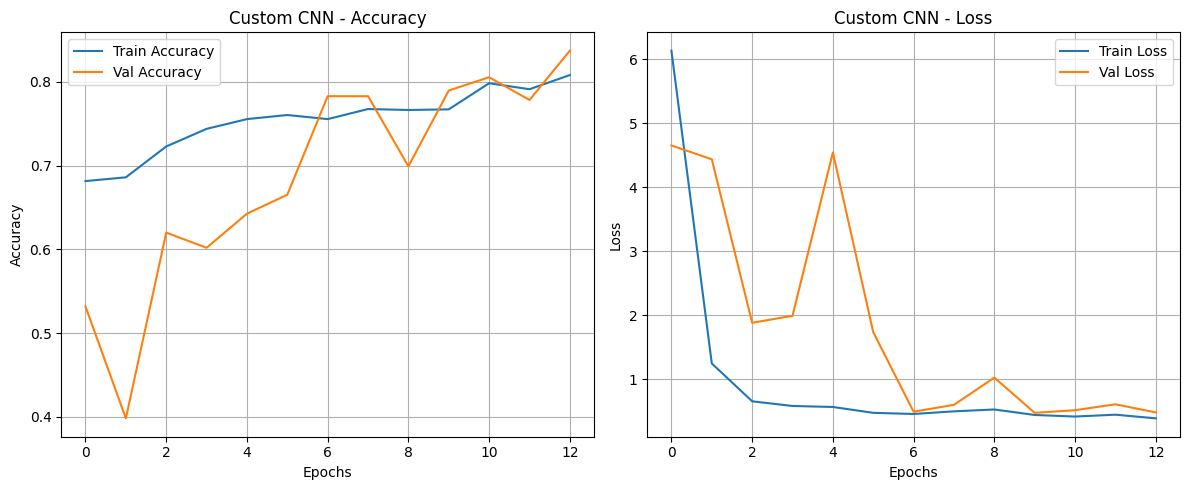

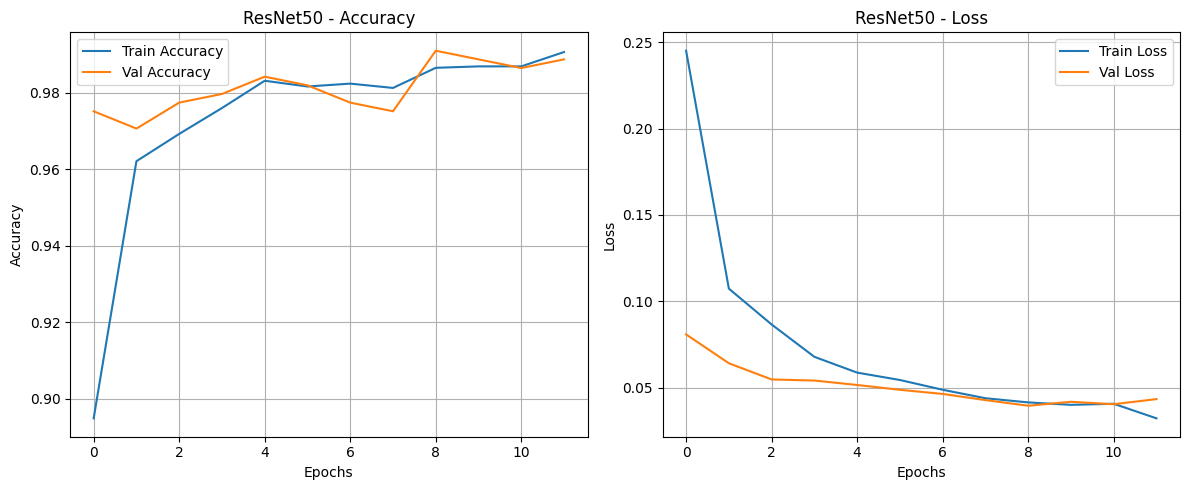

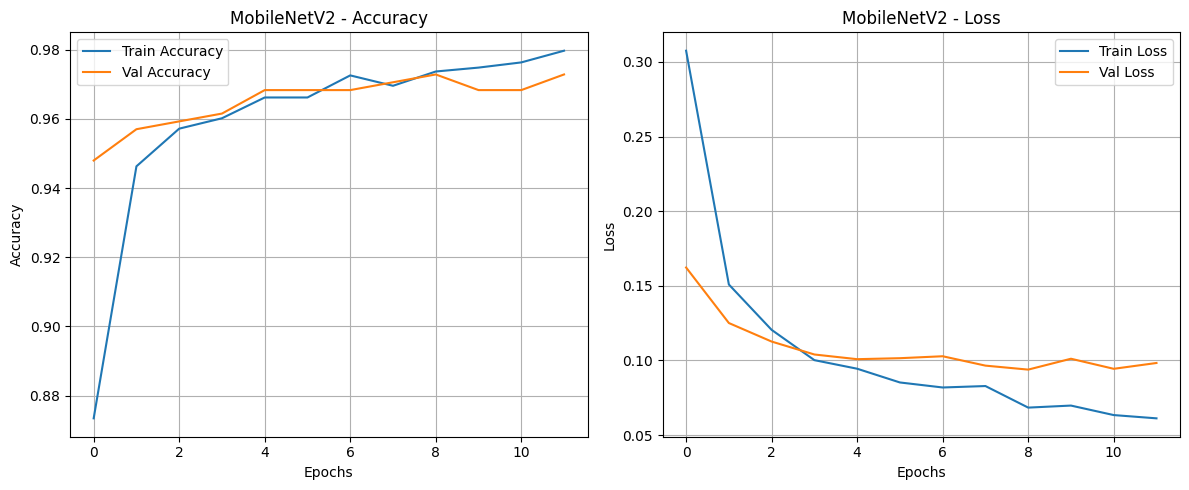

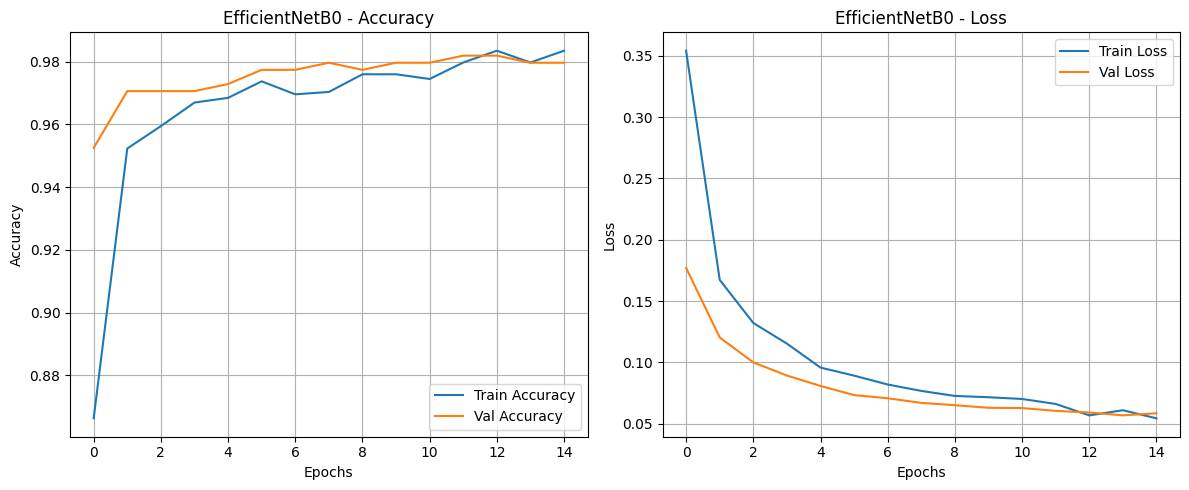

In [ ]:
plot_history(history_cnn, "Custom CNN")
plot_history(history_resnet, "ResNet50")
plot_history(history_mobilenet, "MobileNetV2")
plot_history(history_efficient, "EfficientNetB0")

In [ ]:
def evaluate_model(model, test_ds, model_name, training_time):
    y_true = []
    y_pred_probs = []

    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_pred_probs.extend(preds.flatten())
        y_true.extend(labels.numpy().flatten())

    y_true = np.array(y_true).astype(int)
    y_pred_probs = np.array(y_pred_probs)
    y_pred = (y_pred_probs >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names)

    print(f"\n{'='*50}")
    print(f"{model_name} - Classification Report")
    print(f"{'='*50}")
    print(report)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    val_acc = max(model.history.history['val_accuracy']) if hasattr(model, 'history') else None

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "Training Time (sec)": training_time
    }

In [ ]:
best_cnn = tf.keras.models.load_model(path_cnn)
best_resnet = tf.keras.models.load_model(path_resnet)
best_mobilenet = tf.keras.models.load_model(path_mobilenet)
best_efficient = tf.keras.models.load_model(path_efficient)


Custom CNN - Classification Report
              precision    recall  f1-score   support

        bird       0.89      0.81      0.85       121
       drone       0.78      0.87      0.82        94

    accuracy                           0.84       215
   macro avg       0.84      0.84      0.84       215
weighted avg       0.84      0.84      0.84       215



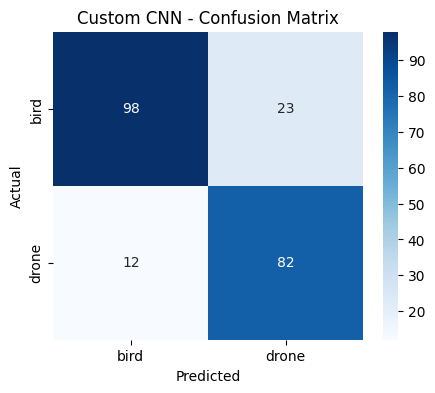


ResNet50 - Classification Report
              precision    recall  f1-score   support

        bird       0.99      1.00      1.00       121
       drone       1.00      0.99      0.99        94

    accuracy                           1.00       215
   macro avg       1.00      0.99      1.00       215
weighted avg       1.00      1.00      1.00       215



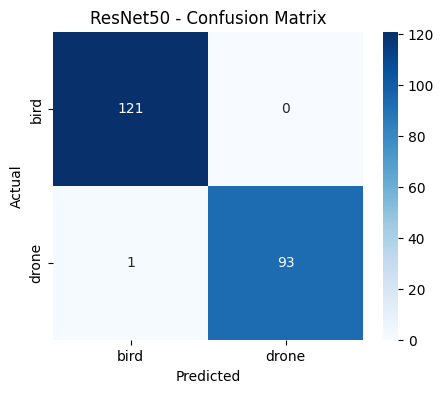


MobileNetV2 - Classification Report
              precision    recall  f1-score   support

        bird       0.97      1.00      0.98       121
       drone       1.00      0.96      0.98        94

    accuracy                           0.98       215
   macro avg       0.98      0.98      0.98       215
weighted avg       0.98      0.98      0.98       215



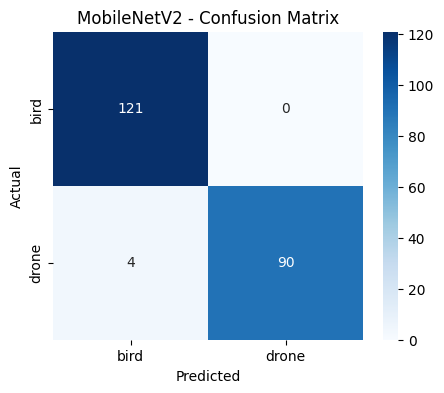


EfficientNetB0 - Classification Report
              precision    recall  f1-score   support

        bird       0.98      0.99      0.99       121
       drone       0.99      0.98      0.98        94

    accuracy                           0.99       215
   macro avg       0.99      0.99      0.99       215
weighted avg       0.99      0.99      0.99       215



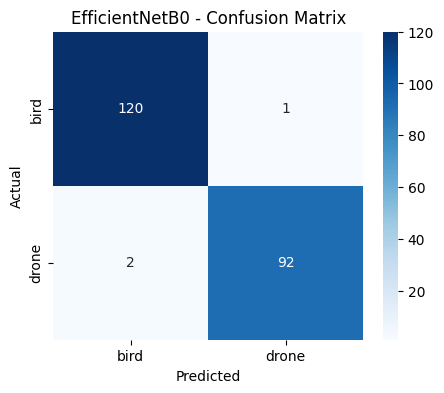

In [ ]:
results = []

results.append(evaluate_model(best_cnn, test_ds_cnn, "Custom CNN", time_cnn))
results.append(evaluate_model(best_resnet, test_ds_resnet, "ResNet50", time_resnet))
results.append(evaluate_model(best_mobilenet, test_ds_mobilenet, "MobileNetV2", time_mobilenet))
results.append(evaluate_model(best_efficient, test_ds_efficient, "EfficientNetB0", time_efficient))

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
0,ResNet50,0.995349,1.000000,0.989362,0.994652,570.829822
1,EfficientNetB0,0.986047,0.989247,0.978723,0.983957,704.046536
2,MobileNetV2,0.981395,1.000000,0.957447,0.978261,502.424139
3,Custom CNN,0.837209,0.780952,0.872340,0.824121,1072.164320


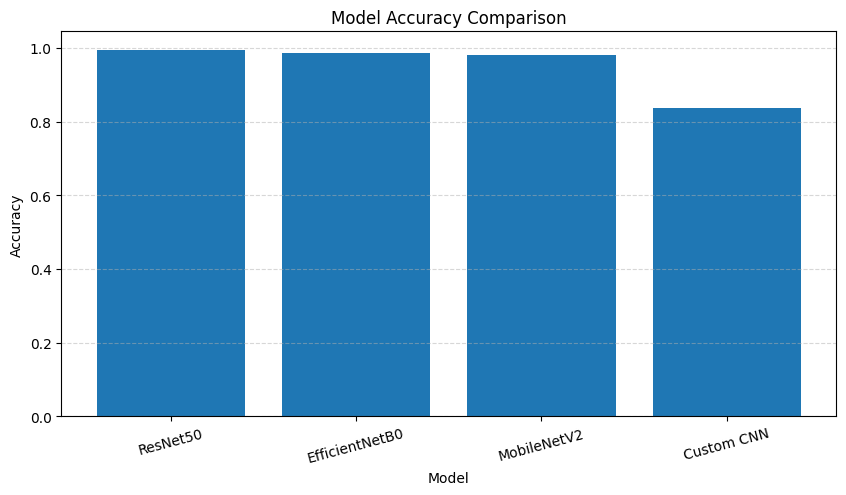

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

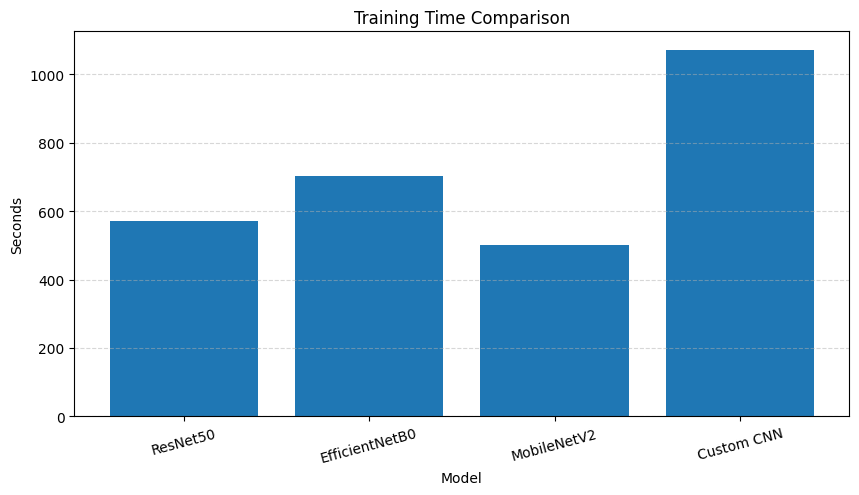

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["Training Time (sec)"])
plt.title("Training Time Comparison")
plt.ylabel("Seconds")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
best_model_name = results_df.loc[0, "Model"]
print("Best Performing Model:", best_model_name)

Best Performing Model: ResNet50


In [ ]:
if best_model_name == "Custom CNN":
    final_best_model = best_cnn
    final_path = "best_model_custom_cnn.keras"

elif best_model_name == "ResNet50":
    final_best_model = best_resnet
    final_path = "best_model_resnet.keras"

elif best_model_name == "MobileNetV2":
    final_best_model = best_mobilenet
    final_path = "best_model_mobilenetv2.keras"

else:
    final_best_model = best_efficient
    final_path = "best_model_efficientnetb0.keras"

final_best_model.save(final_path)
print(f"Best model saved as: {final_path}")

Best model saved as: best_model_resnet.keras


In [ ]:
from google.colab import files
files.download(final_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
best_resnet.save_weights("best_model_resnet.weights.h5")
print("best_model_resnet.weights.h5 saved")

best_model_resnet.weights.h5 saved


In [ ]:
from google.colab import files
files.download("best_model_resnet.weights.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def predict_single_image(model, img_path, preprocess_type="resnet"):
    img = Image.open(img_path).convert("RGB").resize((224, 224))
    img_array = np.array(img).astype("float32")

    if preprocess_type == "resnet":
        img_array = tf.keras.applications.resnet50.preprocess_input(img_array)
    elif preprocess_type == "mobilenet":
        img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
    elif preprocess_type == "efficientnet":
        img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
    else:
        img_array = img_array / 255.0

    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)[0][0]

    if pred >= 0.5:
        label = "drone"
        conf = float(pred)
    else:
        label = "bird"
        conf = float(1 - pred)

    return img, label, conf, float(pred)

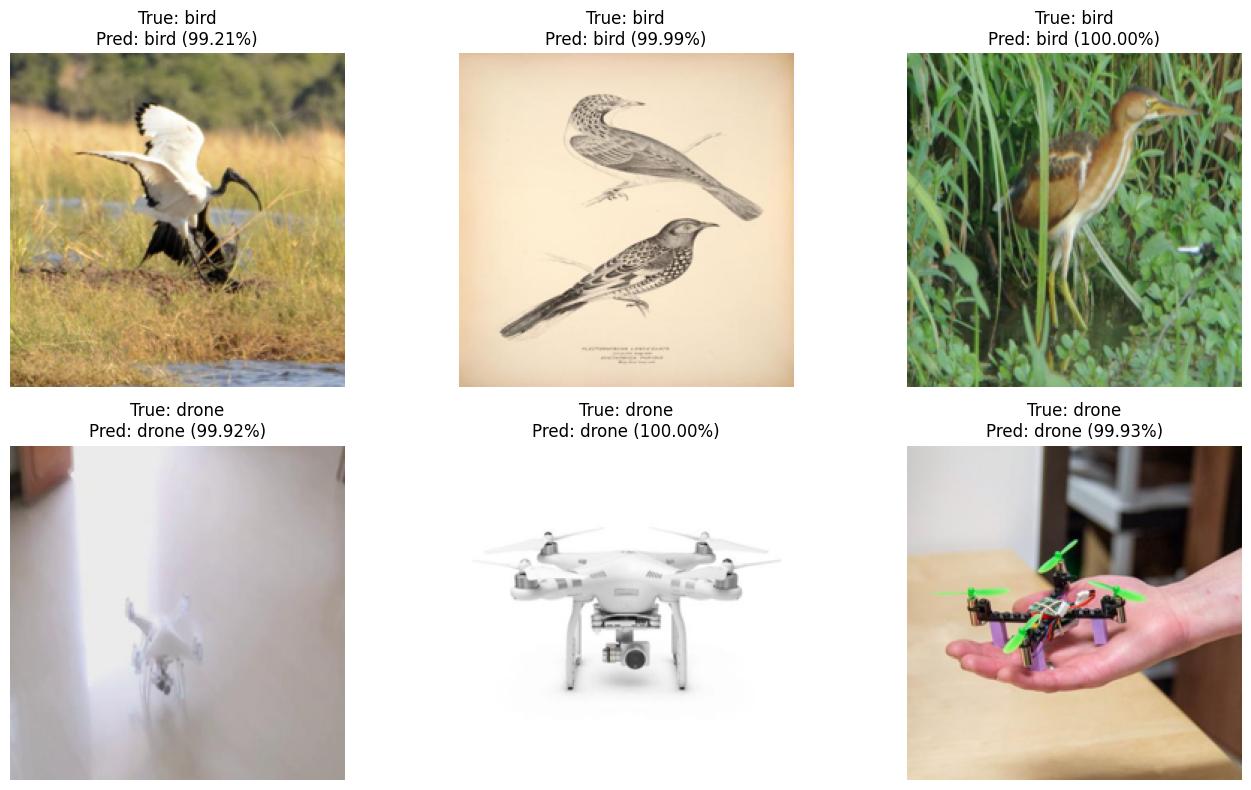

In [ ]:
bird_test_folder = os.path.join(test_path, "bird")
drone_test_folder = os.path.join(test_path, "drone")

sample_paths = []
for _ in range(3):
    sample_paths.append(os.path.join(bird_test_folder, random.choice(os.listdir(bird_test_folder))))
for _ in range(3):
    sample_paths.append(os.path.join(drone_test_folder, random.choice(os.listdir(drone_test_folder))))

plt.figure(figsize=(14, 8))

for i, path in enumerate(sample_paths):
    img, pred_label, conf, raw = predict_single_image(best_resnet, path, preprocess_type="resnet")
    true_label = os.path.basename(os.path.dirname(path))

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label} ({conf:.2%})")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 0b2724a2e00c883b_jpg.rf.99d78b8b4ce0b31ebc4c6d3ab2efd0fb.jpg to 0b2724a2e00c883b_jpg.rf.99d78b8b4ce0b31ebc4c6d3ab2efd0fb.jpg


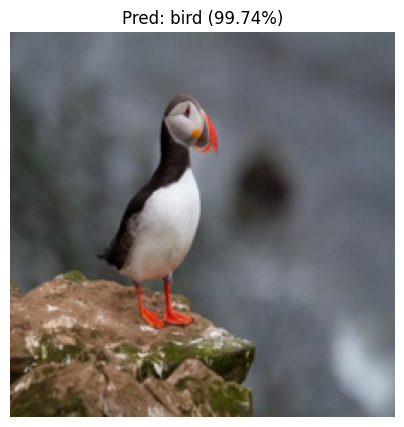

In [ ]:
for filename in uploaded.keys():
    img, pred_label, conf, raw = predict_single_image(best_resnet, filename, preprocess_type="resnet")
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.title(f"Pred: {pred_label} ({conf:.2%})")
    plt.axis("off")
    plt.show()

In [ ]:
best_resnet.save("deploy_resnet_model.keras")
print("Model saved as deploy_resnet_model.keras")

Model saved as deploy_resnet_model.keras


In [ ]:
from google.colab import files
files.download("deploy_resnet_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
best_resnet.save_weights("deploy_resnet_model.weights.h5")
files.download("deploy_resnet_model.weights.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>